## Install the Library

In [48]:
!pip install sentence-transformers

## Import Libraries

In [49]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 10 sentences on 3 topics:
 Cricket, Cooking, and Cybersecurity

In [50]:
sentences = [
    # Cricket (3)
    "The batsman hit a six over the boundary",
    "The bowler delivered a fast yorker",
    "The team won the match by scoring more runs",

    # Cooking (3)
    "I added salt and spices to the curry",
    "The cake was baked in the oven",
    "She chopped vegetables for the salad",

    # Cybersecurity (4)
    "The system was attacked by a hacker",
    "Strong passwords help protect accounts",
    "Encryption keeps data secure",
    "The firewall blocked unauthorized access"
]
len(sentences)

10

## Load Embedding Model

In [51]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Generate Embeddings

In [52]:
embeddings = model.encode(sentences)

## Cosine Similarity

In [53]:
similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)

df

,The batsman hit a six over the boundary,The bowler delivered a fast yorker,The team won the match by scoring more runs,I added salt and spices to the curry,The cake was baked in the oven,She chopped vegetables for the salad,The system was attacked by a hacker,Strong passwords help protect accounts,Encryption keeps data secure,The firewall blocked unauthorized access
The batsman hit a six over the boundary,1.000000,0.400369,0.430195,0.060755,0.127813,0.158446,0.125777,0.004904,0.006343,0.025350
The bowler delivered a fast yorker,0.400369,1.000000,0.328412,0.140060,0.147826,0.237716,0.108514,0.044006,-0.006015,-0.015217
The team won the match by scoring more runs,0.430195,0.328412,1.000000,0.066598,0.121278,0.121045,0.181736,0.004265,0.046071,0.023644
I added salt and spices to the curry,0.060755,0.140060,0.066598,1.000000,0.247276,0.307986,0.119998,0.010171,0.012227,0.126769
The cake was baked in the oven,0.127813,0.147826,0.121278,0.247276,1.000000,0.182638,0.130591,-0.153471,0.107775,0.107838
She chopped vegetables for the salad,0.158446,0.237716,0.121045,0.307986,0.182638,1.000000,0.066000,-0.013131,0.076399,0.023170
The system was attacked by a hacker,0.125777,0.108514,0.181736,0.119998,0.130591,0.066000,1.000000,0.202392,0.210910,0.390278
Strong passwords help protect accounts,0.004904,0.044006,0.004265,0.010171,-0.153471,-0.013131,0.202392,1.000000,0.276734,0.140640
Encryption keeps data secure,0.006343,-0.006015,0.046071,0.012227,0.107775,0.076399,0.210910,0.276734,1.000000,0.146724
The firewall blocked unauthorized access,0.025350,-0.015217,0.023644,0.126769,0.107838,0.023170,0.390278,0.140640,0.146724,1.000000


## Create Heatmap

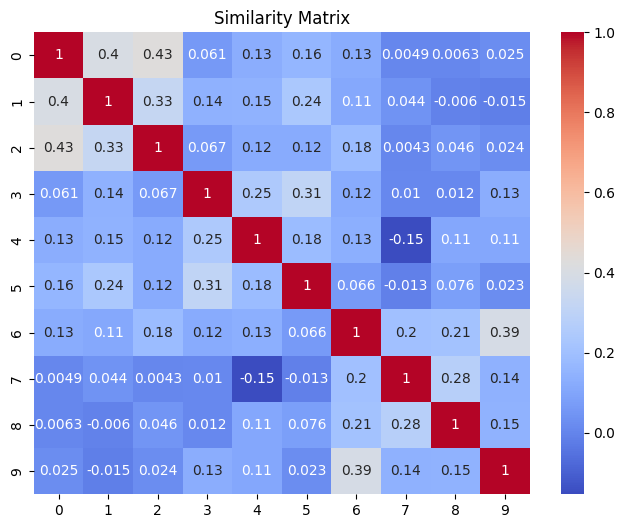

In [54]:
plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Similarity Matrix")
plt.show()

## Query Sentence

In [55]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

## Find Similar Sentences

In [56]:
scores = cosine_similarity(query_embedding, embeddings)[0]

top_indices = np.argsort(scores)[-2:][::-1]

for i in top_indices:
    print("Sentence:", sentences[i])
    print("Score:", scores[i])
    print()

Sentence: The batsman hit a six over the boundary
Score: 0.5741824

Sentence: The bowler delivered a fast yorker
Score: 0.5413827

